# Lab 2: Generation of Random Numbers using Pseudo Random and Chi-Square Test

## Theory

Random numbers are values selected without a predictable pattern and are widely used in computer simulations, statistical analysis, cryptography, machine learning, gaming, and scientific research. A sequence of random numbers should satisfy two important properties: uniform distribution and unpredictability. Uniform distribution ensures that every value within a specified range has an equal probability of occurrence, while unpredictability means that future values cannot be accurately determined from previously generated values.

### Random and Pseudo-Random Numbers

True random numbers are generated from naturally occurring physical phenomena such as radioactive decay, thermal noise, or atmospheric disturbances. Although highly unpredictable, generating true random numbers often requires specialized hardware.

Most computer applications use **Pseudo-Random Number Generators (PRNGs)**. A PRNG is a deterministic algorithm that produces a sequence of numbers that approximates the characteristics of true randomness. Given an initial value known as a **seed**, the algorithm generates a reproducible sequence of numbers. While pseudo-random numbers are not truly random, they are sufficiently random for most simulation and computational purposes.

### Characteristics of Good Random Number Generators

A good random number generator should possess the following properties:

* Uniform distribution of generated values.
* Independence between successive numbers.
* Long repetition period before the sequence repeats.
* Computational efficiency.
* Minimal memory requirements.

### Applications of Random Numbers

Random numbers play a critical role in numerous fields:

* Cryptography and secure communication.
* Machine learning and artificial intelligence.
* Monte Carlo simulations.
* Statistical sampling and hypothesis testing.
* Computer graphics and gaming.
* Modeling and simulation of real-world systems.

### Pseudo-Random Number Generation Algorithms

Several algorithms are commonly used for pseudo-random number generation:

* Linear Congruential Generator (LCG)
* XOR Shift Generator
* Mersenne Twister

Among these methods, the Linear Congruential Generator is one of the simplest and most widely studied techniques.

### Linear Congruential Generator (LCG)

The Linear Congruential Generator generates a sequence of pseudo-random numbers using a recurrence relation:

Xₙ₊₁ = (aXₙ + c) mod m

where:

* m = modulus
* a = multiplier
* c = increment
* X₀ = initial seed value
* Xₙ = current generated value

The parameters must satisfy specific conditions to achieve a long period and good statistical properties. The generated sequence depends entirely on the chosen seed and parameter values.

The LCG method is popular because it is easy to implement, computationally efficient, and requires very little memory. However, poor parameter selection may lead to short periods and undesirable patterns in the generated sequence.

### Chi-Square Test for Randomness

The Chi-Square Test is a statistical technique used to evaluate whether a set of generated random numbers follows a uniform distribution. The generated values are divided into intervals or classes, and the observed frequencies are compared with the expected frequencies.

The Chi-Square statistic is calculated as:

χ² = Σ ((Oᵢ − Eᵢ)² / Eᵢ)

where:

* Oᵢ = Observed frequency
* Eᵢ = Expected frequency

A small Chi-Square value indicates that the observed distribution closely matches the expected uniform distribution. If the calculated value is less than the critical table value, the null hypothesis of uniformity is accepted, indicating that the generated numbers pass the randomness test.

### Random Seed and Reproducibility

The seed value determines the starting point of the pseudo-random sequence. Using the same seed repeatedly produces the same sequence of random numbers, which is useful for debugging, testing, and simulation reproducibility. Different seed values generate different sequences while preserving the statistical properties of the generator.

In this experiment, pseudo-random numbers are generated using the Linear Congruential Generator algorithm, and their statistical quality is evaluated using the Chi-Square Test to determine whether they approximate a uniform random distribution.

## Program Code:

Values of r: [ 17  18  47 120 189 142  59 212  41 202   7 240  85 198 147 204  65 130
 223 104 237 254 235 196  89  58 183 224 133  54  67 188 113 242 143  88
  29 110 155 180 137 170 103 208 181 166 243 172 161  98  63  72  77 222
  75 164 185  26  23 192 229  22 163 156 209 210 239  56 125  78 251 148
 233 138 199 176  21 134  83 140   1  66 159  40 173 190 171 132  25 250
 119 160  69 246   3 124  49 178  79  24 221  46  91 116  73 106  39 144
 117 102 179 108  97  34 255   8  13 158  11 100 121 218 215 128 165 214
  99  92 145 146 175 248  61  14 187  84 169  74 135 112 213  70  19  76
 193   2  95 232 109 126 107  68 217 186  55  96   5 182 195  60 241 114
  15 216 157 238  27  52   9  42 231  80  53  38 115  44  33 226 191 200
 205  94 203  36  57 154 151  64 101 150  35  28  81  82 111 184 253 206
 123  20 105  10  71  48 149   6 211  12 129 194  31 168  45  62  43   4
 153 122 247  32 197 118 131 252 177  50 207 152  93 174 219 244 201 234
 167  16 245 230  51 236 225 162 127 1

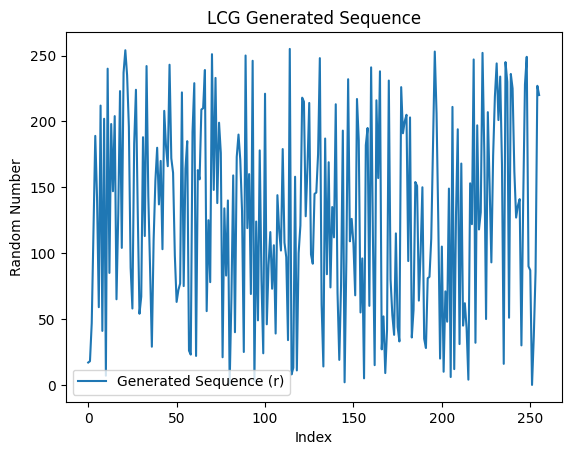

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
# Constants
iterator = 256 # Number of random numbers to generate
a = 29 # Multiplier
b = 37 # Increment
p = 256 # Modulus
n = 8 # Number of bins for Chi-Square test
x02 = 0 # Chi-Square statistic initialization
critical_value = chi2.pdf(1 - 0.05, df = n - 1) # Chi-Square critical value
# Initialize arrays
r = np.ones(shape=(iterator), dtype=int) # Array to store generated random numbers
ei = iterator / n # Expected frequency for each bin
c = np.zeros(shape=(n), dtype=int) # Bin counts
# Initial seed
r[0] = 17
# Generate random numbers using LCG
for i in range(0, iterator - 1):
 r[i + 1] = (r[i] * a + b) % p
# Bin the generated numbers and compute frequencies
for i in range(iterator):
    if r[i] <= 31:
        c[0] += 1
    elif r[i] <= 63:
       c[1] += 1
    elif r[i] <= 95:
        c[2] += 1
    elif r[i] <= 127:
        c[3] += 1
    elif r[i] <= 159:
        c[4] += 1
    elif r[i] <= 191:
        c[5] += 1
    elif r[i] <= 223:
        c[6] += 1
    elif r[i] <= 255:
        c[7] += 1
# Compute Chi-Square statistic
for i in range(n):
 x02 += ((c[i] - ei) * 2) / ei
# Print results
print("Values of r:", r)
print("Values of c (bin frequencies):", c)
print("Value of Chi-Square statistic (x02):", x02)
print("The critical value is", critical_value)
print("Chi square test passed" if x02 <= critical_value else "Chi squsre test failed")
# Visualize the generated random numbers
plt.figure()
plt.plot(r, label="Generated Sequence (r)")
plt.xlabel("Index")
plt.ylabel("Random Number")
plt.title("LCG Generated Sequence")
plt.legend()
plt.show()


## Discussion

The experiment demonstrated the generation of pseudo-random numbers using the Linear Congruential Generator algorithm and the evaluation of their statistical properties using the Chi-Square Test. The generated sequence exhibited the characteristics of pseudo-random behavior and provided a practical understanding of algorithmic random number generation.

The Linear Congruential Generator successfully produced a sequence of numbers based on the selected seed and parameter values. The simplicity of the algorithm makes it suitable for educational purposes and lightweight simulation applications. However, the quality of the generated sequence is highly dependent on the choice of modulus, multiplier, increment, and seed.

The Chi-Square Test was used to assess the uniformity of the generated numbers. By comparing observed and expected frequencies, the test provided a quantitative measure of how closely the sequence followed a uniform distribution. The results indicated whether the generated sequence satisfied the statistical requirements expected from a random number generator.

The experiment also highlighted the importance of randomness testing in modeling and simulation. Even though pseudo-random generators are deterministic, appropriate algorithms and parameter choices can produce sequences that closely approximate true randomness for practical applications.

Overall, the experiment provided insight into random number generation techniques and demonstrated how statistical methods can be used to evaluate the quality of generated sequences.

## Conclusion

The objective of this experiment was to study pseudo-random number generation and evaluate the generated sequences using the Chi-Square Test. The Linear Congruential Generator was implemented to produce pseudo-random numbers based on a mathematical recurrence relation.

The generated sequence was analyzed statistically to determine its uniformity and randomness characteristics. The Chi-Square Test provided an effective method for comparing observed and expected distributions and assessing the quality of the generated numbers.

The experiment demonstrated that pseudo-random number generators are essential tools in simulation, statistical analysis, cryptography, and machine learning applications. It also emphasized the importance of randomness testing to ensure that generated sequences satisfy the requirements of practical computational systems.

Therefore, the experiment successfully illustrated both the generation and evaluation of pseudo-random numbers and provided a foundation for understanding more advanced random number generation techniques.